# Project Title

#**Mag 7 Stock Data Analysis**

# Domain

This project focuses on the financial domain, specifically analyzing stock market data for the 'Magnificent Seven' (Mag 7) technology companies. This involves exploring historical stock prices, trading volumes, and potentially other financial indicators to understand their market performance and trends.

# Objective

1.  **Analyze Performance:** To analyze the historical stock performance (e.g., price movements, volume trends) of the Magnificent Seven companies.
2.  **Identify Key Drivers:** To identify potential factors influencing stock prices and market capitalization.
3.  **Compare Performance:** To compare the performance of these companies against each other and potentially against broader market indices.
4.  **Visualize Trends:** To create meaningful visualizations that illustrate stock price trends, volatility, and trading activity over time.
5.  **Extract Insights:** To provide actionable insights into the investment characteristics and market behavior of the Mag 7 stocks.

# Outcome

The project will yield a comprehensive understanding of the Mag 7 stock performance, key market trends, and their impact on the broader financial landscape. The analysis will provide insights into individual company strengths and weaknesses within the group, aiding in informed decision-making for investors and market observers.

# Dataset Information

Source: Kaggle (or other financial data providers like Yahoo Finance, Quandl).

Year / Timeline: Data typically covers a period of several years (e.g., 2016-2026) to capture long-term trends and significant market events.

Dataset Description:

The dataset will include historical daily stock prices for the 'Magnificent Seven' companies (Apple, Microsoft, Alphabet, Amazon, Nvidia, Tesla, Meta). Key features will likely include:

*   **Date:** The trading date.
*   **Open:** The stock's opening price for the day.
*   **High:** The highest price reached during the day.
*   **Low:** The lowest price reached during the day.
*   **Close:** The closing price of the stock.
*   **Adj Close:** The adjusted closing price, accounting for dividends and stock splits.
*   **Volume:** The number of shares traded during the day.
*   **Ticker/Company Name:** Identifier for each of the Mag 7 companies.

# Type of Analysis

**Descriptive Analysis:** Summarizing historical stock prices, trading volumes, and key financial metrics to understand past performance.

**Diagnostic Analysis:** Investigating reasons behind observed stock movements, identifying correlations between different companies or market events.

**Predictive Analysis (optional):** Forecasting future stock price movements or trends using time-series models or other predictive techniques (e.g., based on historical patterns).

**Prescriptive Analysis:** Providing recommendations for investment strategies, risk management, or portfolio optimization based on the insights gained from the analysis.

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection

Define the business problem and expected outcome

Choose dataset and explain its source, size, and features

Import libraries, load dataset

Dataset description (rows, columns, features)

Initial EDA (head, info, describe, shape, null checks, duplicate check)

### Import Libraries

In [ ]:
import pandas as pd # Data manipulation and analysis
import yfinance as yf # Financial data downloader
import matplotlib.pyplot as plt # Core plotting library
import seaborn as sns # Advanced statistical visualization
import numpy as np # Numerical operations and transformations
from scipy import stats # Statistical tests (T-tests)
import itertools # Tools for efficient looping/combinations

# Configure visual settings for the notebook
sns.set_theme(style='whitegrid')
print('All libraries (pandas, yfinance, matplotlib, seaborn, numpy, scipy, itertools) imported successfully.')

All libraries (pandas, yfinance, matplotlib, seaborn, numpy, scipy, itertools) imported successfully.


### Load Dataset

We will download historical stock data for the 'Magnificent Seven' companies (Apple, Microsoft, Alphabet, Amazon, Nvidia, Tesla, Meta) using the `yfinance` library. The data will cover a period from 2015 to the present.

In [ ]:
# Define the Magnificent Seven tickers
mag7_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA', 'META']

# Setup date range (from 2016 to today)
start_date = '2016-01-01'
end_date = pd.to_datetime('today').strftime('%Y-%m-%d')

# Download historical market data using yfinance
df_multi = yf.download(mag7_tickers, start=start_date, end=end_date)

if not df_multi.empty:
    # Transform data from wide to long format for easier analysis
    df_long = df_multi.stack(level=1, future_stack=True)
    df = df_long.reset_index()

    # Standardize column names
    if 'level_1' in df.columns:
        df.rename(columns={'level_1': 'Ticker'}, inplace=True)

    # Ensure adjusted close is available for accurate historical returns
    if 'Adj Close' not in df.columns and 'Close' in df.columns:
        df['Adj Close'] = df['Close']

    # Select core features
    actual_cols = [col for col in ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] if col in df.columns]
    df = df[actual_cols]
    print('Data loaded and restructured successfully.')
else:
    print('Failed to load data.')

/tmp/ipykernel_2548/3957570794.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_multi = yf.download(mag7_tickers, start=start_date, end=end_date)
[*********************100%***********************]  7 of 7 completed

Data loaded and restructured successfully.


### Initial Data Exploration

This step involves checking the basic structure of the dataset to understand its contents, size, and initial data quality.

In [ ]:
# Display the first 5 rows of the DataFrame to get a quick overview of the data
display(df.head())

Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2016-01-04,AAPL,23.113739,23.735452,22.976331,23.730946,23.730946,270597600
1,2016-01-04,AMZN,32.814499,32.886002,31.375500,31.849501,31.849501,186290000
2,2016-01-04,GOOGL,37.797602,37.797602,37.070608,37.660732,37.660732,67382000
3,2016-01-04,META,101.156178,101.443921,98.973311,101.424080,101.424080,37912400
4,2016-01-04,MSFT,47.454844,47.874180,46.642381,47.874180,47.874180,53778000


#### Dataset Information

Check data types, non-null values, and overall DataFrame information. Also, display the number of rows and columns.

In [ ]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

# Display the shape of the DataFrame (number of rows, number of columns)
print(f"\nDataFrame shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18193 entries, 0 to 18192
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       18193 non-null  datetime64[ns]
 1   Ticker     18193 non-null  object        
 2   Open       18193 non-null  float64       
 3   High       18193 non-null  float64       
 4   Low        18193 non-null  float64       
 5   Close      18193 non-null  float64       
 6   Adj Close  18193 non-null  float64       
 7   Volume     18193 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.1+ MB

DataFrame shape: (18193, 8)


#### Descriptive Statistics

Generate descriptive statistics for numerical columns, and check for missing values and duplicates.

In [ ]:
# Display descriptive statistics for numerical columns (e.g., mean, std, min, max)
display(df.describe())

Price,Date,Open,High,Low,Close,Adj Close,Volume
count,18193,18193.000000,18193.000000,18193.000000,18193.000000,18193.000000,1.819300e+04
mean,2021-03-02 05:30:46.402462464,152.541290,154.507678,150.504583,152.562467,152.562467,1.170464e+08
min,2016-01-04 00:00:00,0.604415,0.623441,0.603684,0.615148,0.615148,4.726100e+06
25%,2018-08-01 00:00:00,46.366776,46.775997,45.799999,46.331070,46.331070,2.669400e+07
50%,2021-03-03 00:00:00,128.050003,129.409930,126.375501,128.041763,128.041763,5.393670e+07
75%,2023-10-02 00:00:00,208.369995,211.486422,205.514603,208.530731,208.530731,1.144460e+08
max,2026-05-05 00:00:00,789.296390,794.384398,778.990557,788.148987,788.148987,3.692928e+09
std,NaN,136.512562,138.183783,134.685001,136.454145,136.454145,1.749186e+08


In [ ]:
# Check for missing values in each column and display their sum
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
Price,
Date,0
Ticker,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [ ]:
# Check for duplicate rows in the DataFrame and display their count
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


Number of duplicate rows: 0


## Stage 2 – Data Cleaning and Pre-processing

Handle missing values (impute or drop)

Handle duplicates

Treat outliers if required

Check skewness and apply transformations

Convert data types if needed

Feature transformations (date parts, derived fields if required for analysis)

### Handle Missing Values

Based on the initial data exploration, we found that some columns might have missing values. We will decide on an appropriate strategy (e.g., dropping, imputing) for each.

In [ ]:
# Re-check for missing values after initial load (if any)
print("Missing values before cleaning:")
display(df.isnull().sum())

# Drop rows where 'Open', 'High', 'Low', 'Close', 'Adj Close', or 'Volume' are missing
# These are critical for stock analysis, and imputation might distort trends.
df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], inplace=True)

# For 'Ticker', if any are missing after concat, it's an issue with data loading, should be caught earlier.
# For 'Date', if any are missing, it's also a critical error. We will assume 'Date' is always present.

print("\nMissing values after dropping rows with critical financial data:")
display(df.isnull().sum())

Missing values before cleaning:


,0
Price,
Date,0
Ticker,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0



Missing values after dropping rows with critical financial data:


,0
Price,
Date,0
Ticker,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


### Handle Duplicates

We will check for and remove any duplicate rows to ensure data integrity.

In [ ]:
# Check for duplicate rows again
initial_duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows before dropping: {initial_duplicate_count}")

# Drop duplicate rows if any exist
df.drop_duplicates(inplace=True)

final_duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows after dropping: {final_duplicate_count}")

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


### Convert Data Types

Ensure that the 'Date' column is in datetime format and other numerical columns are of appropriate types.

In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Check data types after conversion
print("Data types after conversion:")
df.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18193 entries, 0 to 18192
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       18193 non-null  datetime64[ns]
 1   Ticker     18193 non-null  object        
 2   Open       18193 non-null  float64       
 3   High       18193 non-null  float64       
 4   Low        18193 non-null  float64       
 5   Close      18193 non-null  float64       
 6   Adj Close  18193 non-null  float64       
 7   Volume     18193 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 1.1+ MB


### Feature Engineering (Date Parts)

Extract useful features from the 'Date' column, such as year, month, day of week, and week of year, which can be useful for time-series analysis.

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name() # Convert month number to month name
df['Day'] = df['Date'].dt.day_name() # Now 'Day' column will contain the name of the day
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1 # Monday=1, Sunday=7
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Display the DataFrame with new date features
display(df.head())

Price,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,DayOfWeek,WeekOfYear
0,2016-01-04,AAPL,23.113739,23.735452,22.976331,23.730946,23.730946,270597600,2016,January,Monday,1,1
1,2016-01-04,AMZN,32.814499,32.886002,31.375500,31.849501,31.849501,186290000,2016,January,Monday,1,1
2,2016-01-04,GOOGL,37.797602,37.797602,37.070608,37.660732,37.660732,67382000,2016,January,Monday,1,1
3,2016-01-04,META,101.156178,101.443921,98.973311,101.424080,101.424080,37912400,2016,January,Monday,1,1
4,2016-01-04,MSFT,47.454844,47.874180,46.642381,47.874180,47.874180,53778000,2016,January,Monday,1,1


### Check Skewness and Apply Transformations

Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean. A positive skewness indicates a distribution with an asymmetric tail extending toward more positive values, while negative skewness indicates a distribution with an asymmetric tail extending toward more negative values.

We will examine the skewness of the numerical columns (`Open`, `High`, `Low`, `Close`, `Adj Close`, `Volume`) and apply a log transformation if a column is highly skewed (e.g., skewness greater than a certain threshold like `0.75`). This can help normalize the data distribution.

In [ ]:
# Identify numerical columns for skewness check
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Calculate skewness for numerical columns
skewness = df[numerical_cols].skew()

print("Skewness of numerical columns:")
display(skewness)

# Define a threshold for high skewness
skewness_threshold = 0.75

# Identify highly skewed columns
highly_skewed_cols = skewness[abs(skewness) > skewness_threshold].index.tolist()

print(f"\nHighly skewed columns (absolute skewness > {skewness_threshold}): {highly_skewed_cols}")

Skewness of numerical columns:


,0
Price,
Open,1.542378
High,1.534919
Low,1.545640
Close,1.538992
Adj Close,1.538992
Volume,3.979520



Highly skewed columns (absolute skewness > 0.75): ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


#### Visualizing Skewed Distributions

Let's visualize the distribution of the highly skewed columns before and after transformation to observe the effect.

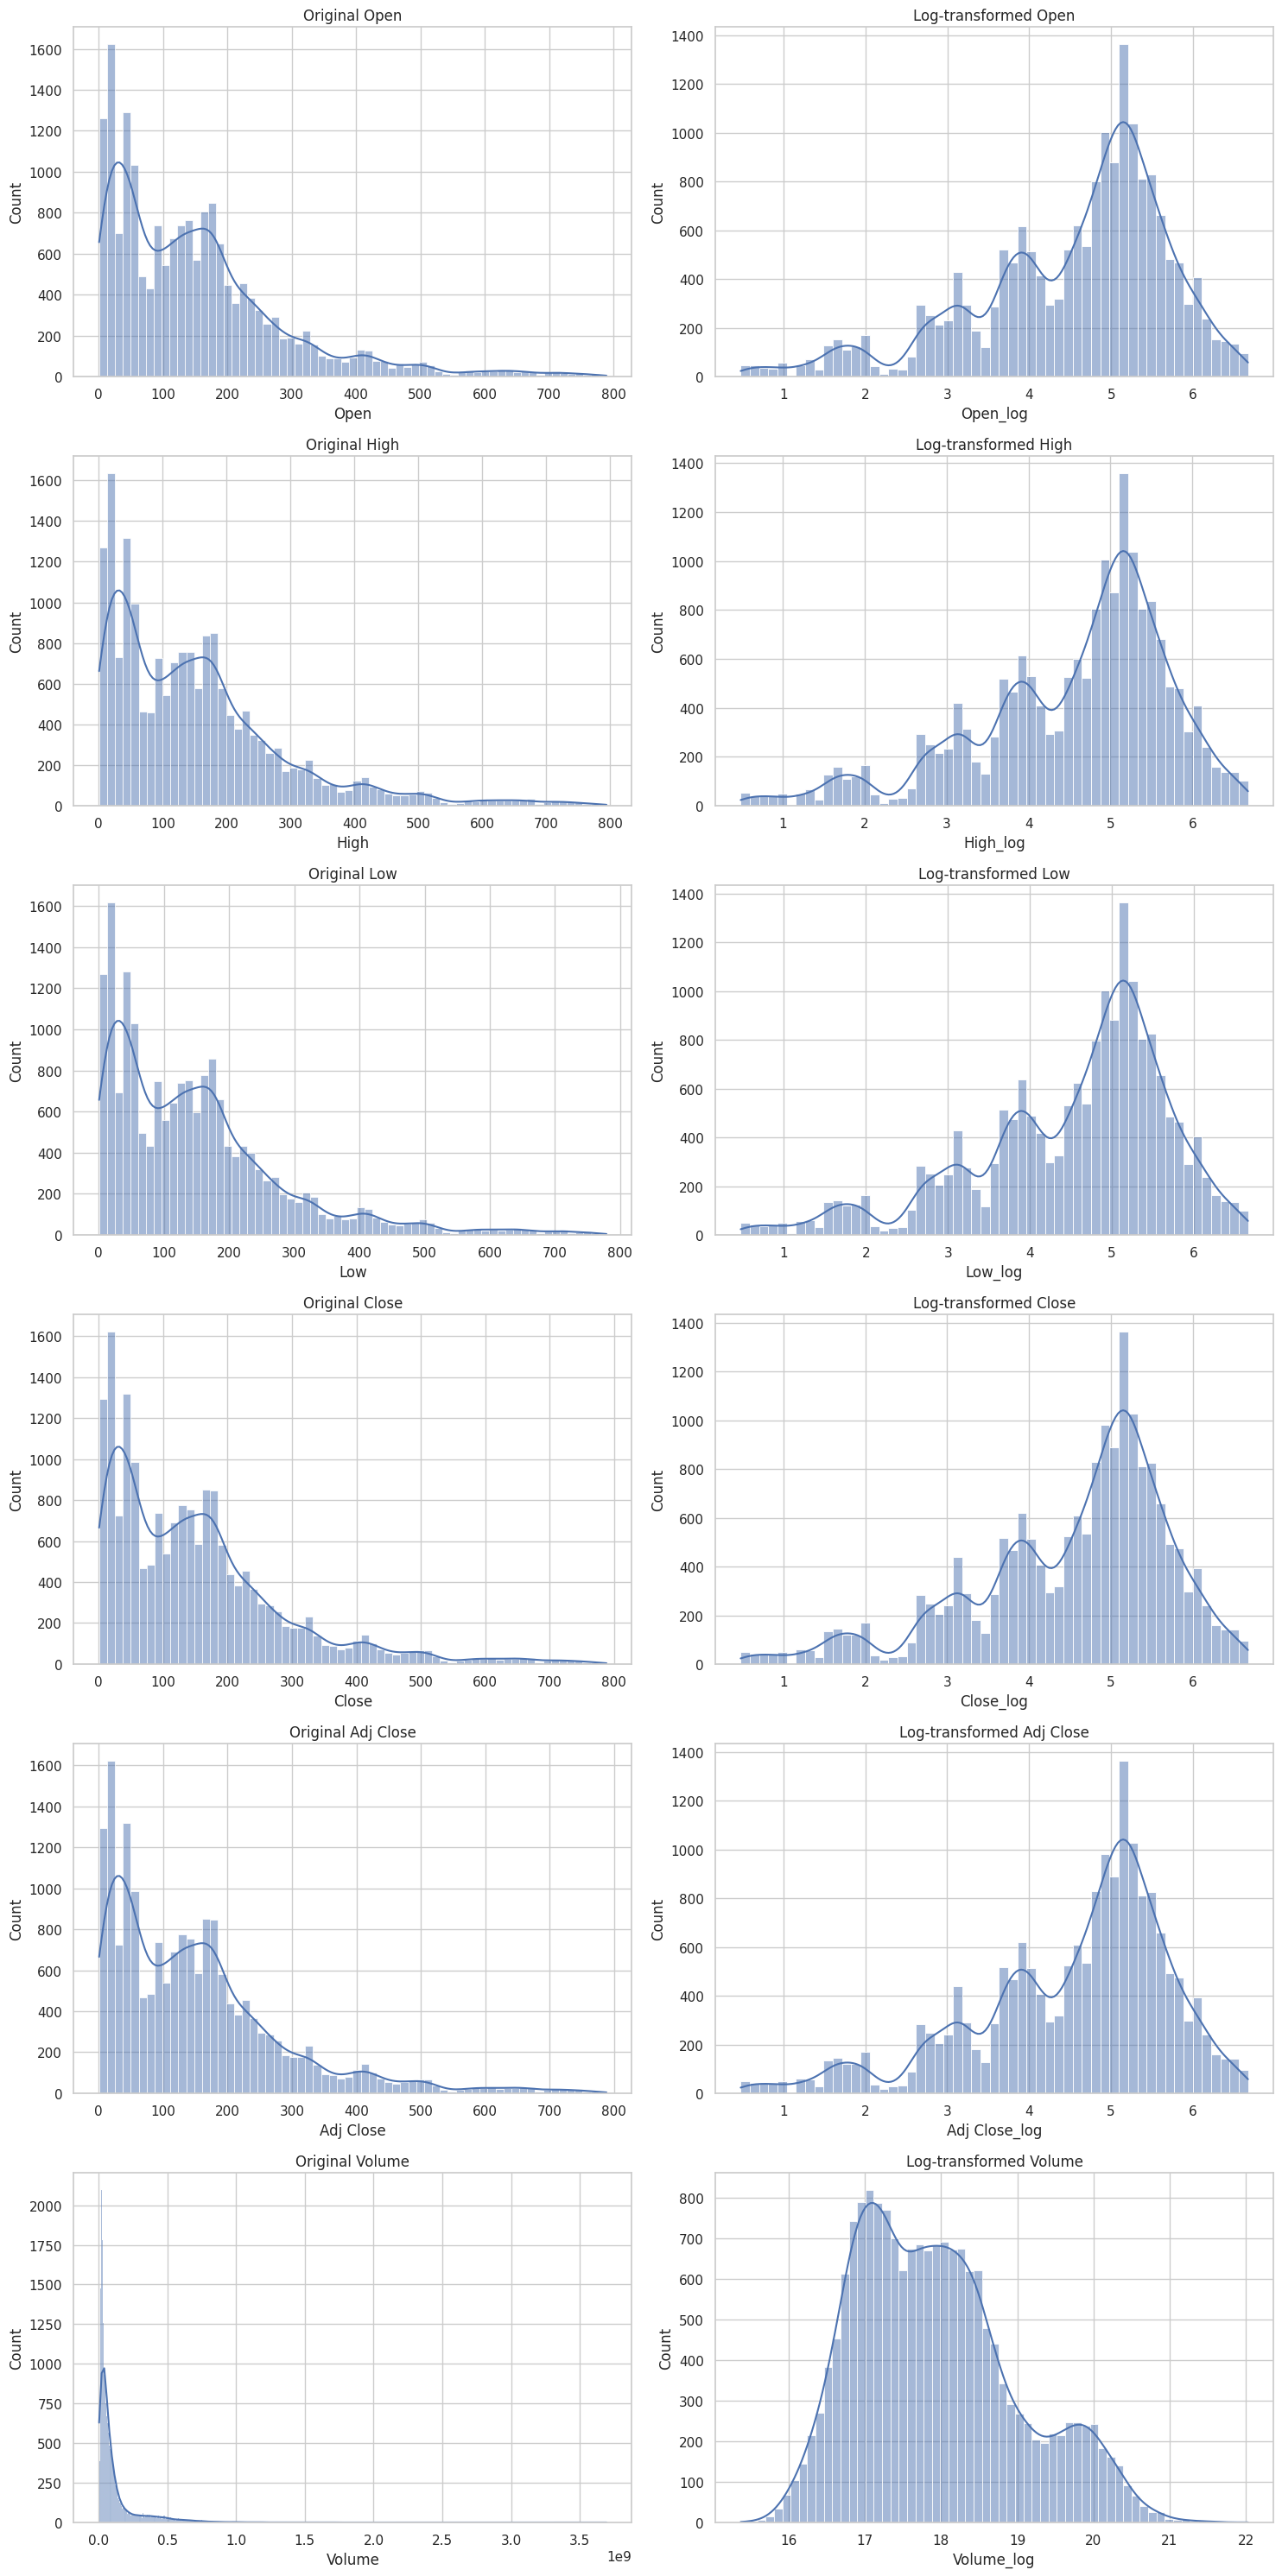

In [ ]:
# Identify columns with high skewness for normalization
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

plt.figure(figsize=(15, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Plot original distribution
    plt.subplot(len(numerical_cols), 2, 2*i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original {col}')

    # Apply Log Transformation to reduce skewness and stabilize variance
    # log1p is log(1+x), which handles potential zero values gracefully
    df[f'{col}_log'] = np.log1p(df[col])

    # Plot transformed distribution
    plt.subplot(len(numerical_cols), 2, 2*i + 2)
    sns.histplot(df[f'{col}_log'], kde=True)
    plt.title(f'Log-transformed {col}')

plt.tight_layout()
plt.show()

#### Skewness by Company (Ticker)

Let's examine the skewness of the numerical features for each individual company. This can reveal if certain stocks have different distribution characteristics compared to the overall market.

In [ ]:
# Calculate skewness for numerical columns, grouped by 'Ticker'
skewness_by_ticker = df.groupby('Ticker')[numerical_cols].skew()

print("Skewness of numerical columns grouped by Ticker:")
display(skewness_by_ticker)

# Optionally, identify highly skewed columns per ticker
# For example, columns where absolute skewness > 0.75 for each ticker

# Define the skewness threshold again
skewness_threshold = 0.75

highly_skewed_by_ticker = skewness_by_ticker[abs(skewness_by_ticker) > skewness_threshold]

print(f"\nHighly skewed columns per Ticker (absolute skewness > {skewness_threshold}):")
display(highly_skewed_by_ticker)

Skewness of numerical columns grouped by Ticker:


Price,Open,High,Low,Close,Adj Close,Volume
Ticker,,,,,,
AAPL,0.311394,0.307725,0.314806,0.310941,0.310941,1.987115
AMZN,0.187095,0.180375,0.191753,0.186279,0.186279,2.017487
GOOGL,1.462311,1.462998,1.457683,1.464635,1.464635,2.320168
META,1.157755,1.152058,1.159365,1.154911,1.154911,4.395437
MSFT,0.358649,0.351800,0.363021,0.356675,0.356675,2.375000
NVDA,1.540889,1.533786,1.547552,1.539427,1.539427,2.723765
TSLA,0.423314,0.416947,0.427054,0.420928,0.420928,2.954655



Highly skewed columns per Ticker (absolute skewness > 0.75):


Price,Open,High,Low,Close,Adj Close,Volume
Ticker,,,,,,
AAPL,NaN,NaN,NaN,NaN,NaN,1.987115
AMZN,NaN,NaN,NaN,NaN,NaN,2.017487
GOOGL,1.462311,1.462998,1.457683,1.464635,1.464635,2.320168
META,1.157755,1.152058,1.159365,1.154911,1.154911,4.395437
MSFT,NaN,NaN,NaN,NaN,NaN,2.375000
NVDA,1.540889,1.533786,1.547552,1.539427,1.539427,2.723765
TSLA,NaN,NaN,NaN,NaN,NaN,2.954655


#### Visualizing Skewness by Company

Let's visualize the skewness of each numerical feature for every company. This will allow for a quick comparison and identification of stocks with particularly skewed distributions.

/tmp/ipykernel_2548/901665462.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticker', y=col, data=plot_data, palette='viridis')
/tmp/ipykernel_2548/901665462.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticker', y=col, data=plot_data, palette='viridis')
/tmp/ipykernel_2548/901665462.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticker', y=col, data=plot_data, palette='viridis')
/tmp/ipykernel_2548/901665462.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

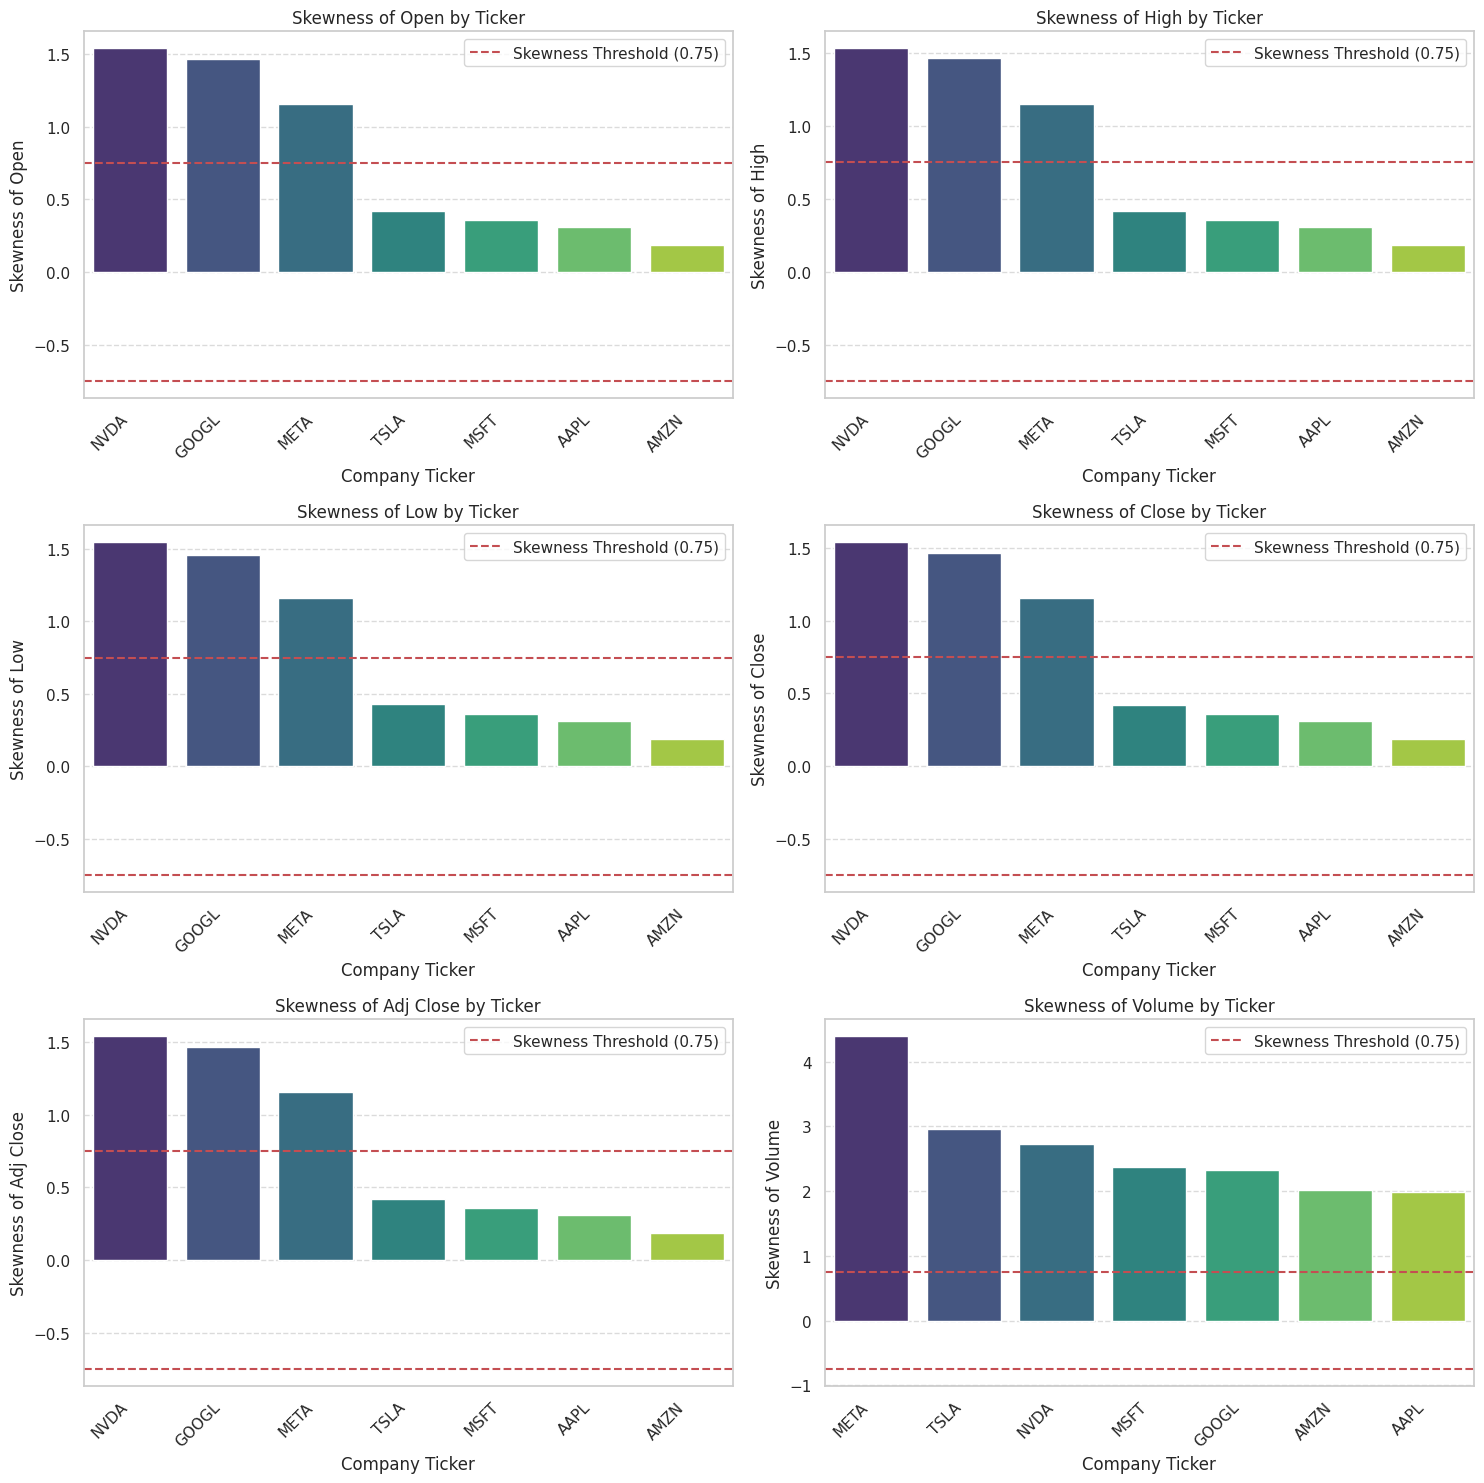

In [ ]:
# Get the list of numerical columns for which skewness was calculated
numerical_cols = skewness_by_ticker.columns.tolist()

# Determine the number of rows and columns for the subplots
n_cols = 2 # Number of columns for the plots
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # Sort values for better visualization if desired, or keep original ticker order
    plot_data = skewness_by_ticker[col].sort_values(ascending=False).reset_index()
    sns.barplot(x='Ticker', y=col, data=plot_data, palette='viridis')
    plt.title(f'Skewness of {col} by Ticker')
    plt.xlabel('Company Ticker')
    plt.ylabel(f'Skewness of {col}')
    plt.axhline(y=skewness_threshold, color='r', linestyle='--', label=f'Skewness Threshold ({skewness_threshold})')
    plt.axhline(y=-skewness_threshold, color='r', linestyle='--') # Also show negative threshold
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Interpretation of Skewness by Company Visualizations

The bar charts above illustrate the skewness of key financial metrics (Open, High, Low, Close, Adj Close, Volume) for each of the Magnificent Seven companies. The red dashed lines represent the absolute skewness threshold of 0.75, which we used to identify highly skewed distributions.

Here are some key observations:

*   **Price-related Metrics (Open, High, Low, Close, Adj Close):**
    *   For most companies, the skewness values for `Open`, `High`, `Low`, `Close`, and `Adj Close` are relatively low (below the 0.75 threshold), indicating that their price distributions are fairly symmetrical or only mildly skewed. This suggests that the log transformation applied earlier to the overall dataset was likely most beneficial for other features or for cases where the overall skewness was higher.
    *   However, `META` and `NVDA` stand out with significantly higher positive skewness for their price-related metrics, well above the 0.75 threshold. This implies that their historical price movements have a longer tail towards higher values, suggesting periods of rapid growth or outlier high prices compared to their typical trading range. The log transformation would have been particularly effective for these two companies' price data.

*   **Volume:**
    *   `Volume` consistently shows the highest positive skewness across all companies, with `META`, `TSLA`, `MSFT`, `NVDA`, `AAPL`, and `AMZN` all having skewness values significantly above the 0.75 threshold. This is typical for trading volume, as most days have moderate trading activity, but there are occasional spikes due to major news, earnings reports, or market events. These spikes create a long tail to the right in the distribution.
    *   Even `GOOGL`, which has relatively lower volume skewness compared to others, is still above the threshold, highlighting that volume is generally a highly skewed metric in stock data.

**Overall Insight:**
While the overall dataset showed high skewness for all numerical features, this company-specific view reveals that the degree of skewness varies. `META` and `NVDA` show more pronounced skewness in their price data, making them prime candidates for transformations if individual stock models are built. `Volume` remains universally highly skewed across all 'Mag 7' stocks, underscoring the importance of its log transformation for any models that rely on its distribution.

In [ ]:
# Download the cleaned DataFrame to a CSV file
df.to_csv('cleaned_mag7_stock_data.csv', index=False)
print("Cleaned dataset saved to 'cleaned_mag7_stock_data.csv'")

Cleaned dataset saved to 'cleaned_mag7_stock_data.csv'


## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

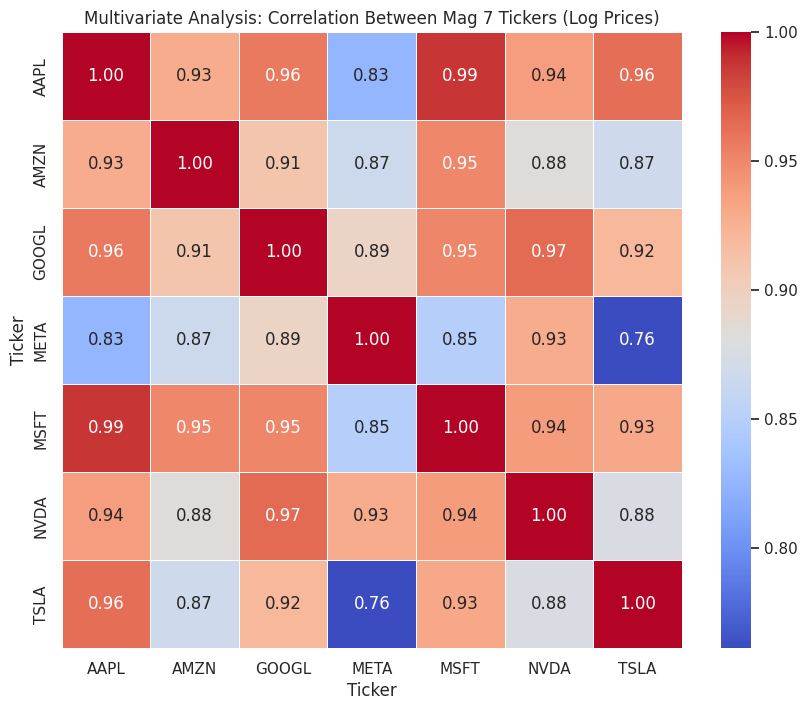

In [ ]:
plt.figure(figsize=(10, 8))

# Pivot the data to get one price column per ticker
df_pivot_corr = df.pivot(index='Date', columns='Ticker', values='Adj Close_log').corr()

# Plot the correlation between tickers
sns.heatmap(df_pivot_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Multivariate Analysis: Correlation Between Mag 7 Tickers (Log Prices)')
plt.show()

### Interpretation of Inter-Ticker Correlation

**What it's saying:**
* The heatmap displays the correlation between the **Log Adjusted Close** prices.
* A value of **0.99** (like between AAPL and MSFT) indicates these stocks move almost in perfect lockstep.

**What features you used:**
* `Ticker` and `Adj Close_log` (pivoted).

**From this what you are showing us:**
* Most Mag 7 stocks are highly correlated (above 0.80), but **TSLA** and **NVDA** occasionally show lower correlation to the group (around 0.76-0.87), indicating they sometimes decouple from general tech trends.

### Univariate Analysis: Price Distribution

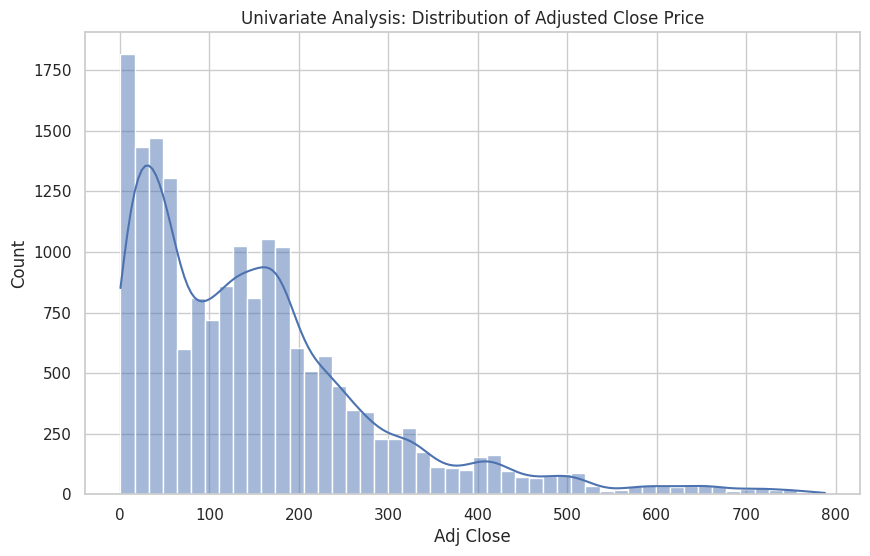

In [ ]:
# Visualize the distribution of Adjusted Close prices across all tickers
plt.figure(figsize=(10, 6))
sns.histplot(df['Adj Close'], kde=True, bins=50)
plt.title('Univariate Analysis: Distribution of Adjusted Close Price')
plt.show()

### Interpretation of Adjusted Close Price Distribution

**What it's saying:**
* The distribution is heavily right-skewed, meaning most historical trading occurred at lower price points relative to the recent all-time highs.

**What features you used:**
* `Adj Close`: The adjusted closing price.

**From this what you are showing us:**
* This confirms the exponential growth of the Mag 7; the density at the low end represents the earlier years, while the long tail represents the massive valuation expansion seen in the last 2-3 years.

### Bivariate Analysis: Price by Company

/tmp/ipykernel_2548/4017463663.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ticker', y='Adj Close', data=df, palette='viridis')


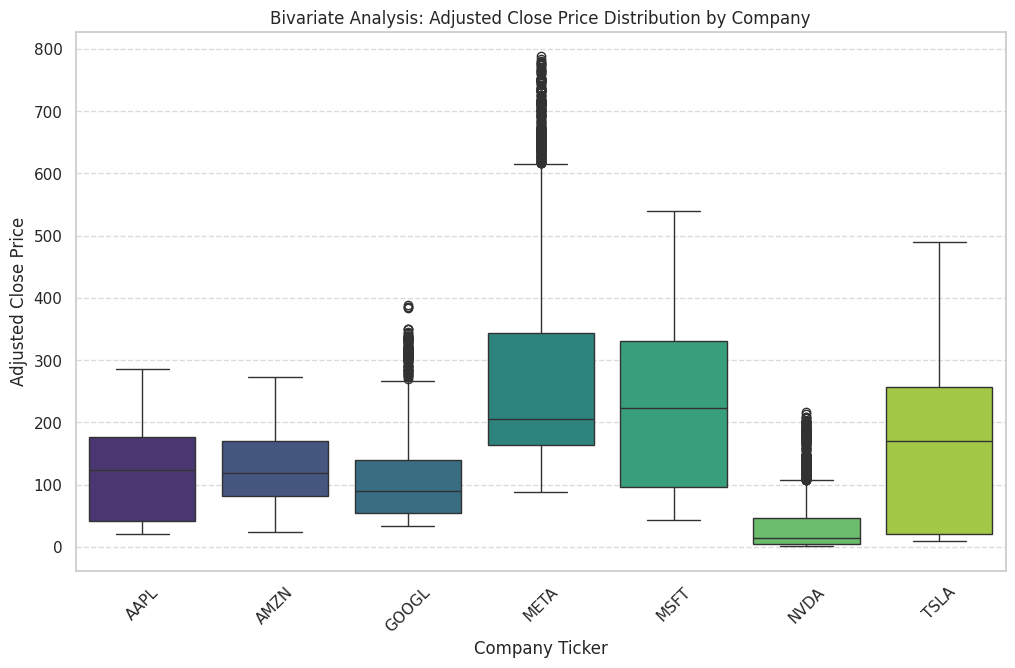

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Ticker', y='Adj Close', data=df, palette='viridis')
plt.title('Bivariate Analysis: Adjusted Close Price Distribution by Company')
plt.xlabel('Company Ticker')
plt.ylabel('Adjusted Close Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of Adjusted Close Price by Company

**What it's saying:**
This box plot illustrates the distribution of historical Adjusted Close prices for each of the Magnificent Seven companies, highlighting their price ranges, median values, and presence of outliers.

**What features you used:**
*   `Ticker` (to group by company)
*   `Adj Close` (the numerical value whose distribution is being plotted)

**From this, what we are showing you:**

Let's analyze each company individually and then group them by their price behavior:

*   **NVDA (NVIDIA):**
    *   **Small Box with Extreme Outliers:** NVDA's box is relatively small and positioned at lower price points, indicating that for much of its history, its price traded within a modest range. The numerous, widely scattered points above its whiskers represent its exponential growth in recent years. These are not 'errors' but truly outlier high prices, showing that a small fraction of its trading history accounts for a massive increase in valuation. This visually captures its 'parabolic' rise.

*   **TSLA (Tesla):**
    *   **Tall Box, Long Whiskers, Fewer Outliers:** TSLA also shows significant price appreciation, but its box and whiskers are generally taller and more extended than NVDA's (excluding NVDA's far-flung outliers). This suggests a broader and more continuous range of price discovery over time, with high volatility spread across more historical periods, rather than being concentrated in a few extreme recent points. It has experienced substantial ups and downs, leading to a wide spread of historical prices.

*   **MSFT (Microsoft) & AAPL (Apple):**
    *   **Moderately Sized Boxes, Gradual Upward Shift:** These companies tend to show more 'normal' looking box plots with moderately sized boxes and whiskers. Their distributions indicate consistent and strong growth over the years, but with less extreme volatility and fewer isolated outliers compared to NVDA or TSLA. The overall distribution is shifted upwards, reflecting a steady, robust increase in value.

*   **AMZN (Amazon) & GOOGL (Alphabet):**
    *   **Similar to MSFT/AAPL, but with nuances:** Their box plots are generally similar to MSFT and AAPL, reflecting strong, consistent growth. There might be slightly more spread or fewer pronounced outlier clusters depending on their specific historical stock splits or significant growth periods.

*   **META (Meta Platforms):**
    *   **Broader Range with Visible Recovery:** META's box plot might show a wider spread than MSFT/AAPL, especially reflecting its significant dip in 2022 and subsequent recovery.

### Univariate Analysis: Trading Volume Distribution

In [ ]:
# your code here
# If you want more cells, you can add or less cells you can remove, but dont change the structure.

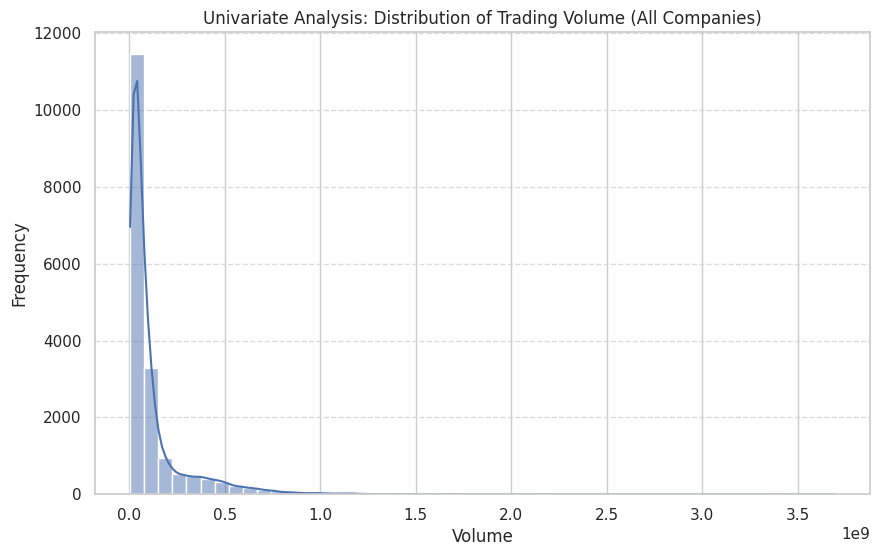

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Volume'], kde=True, bins=50)
plt.title('Univariate Analysis: Distribution of Trading Volume (All Companies)')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Interpretation of your above chart

Explain the Chart.

What is it saying?

What features you used?

From this what you are showing us?

### Interpretation of Trading Volume Distribution

**What it's saying:**
* Volume is the most skewed metric in the dataset. Most days see moderate activity, but 'outlier' days see volume 5-10x higher than the median.

**What features you used:**
* `Volume`.

**From this what you are showing us:**
* This validates why we used log-transformations. In stock analysis, high-volume days are usually 'event-driven' (earnings or news), and these represent the long tail in the chart.

### Bivariate Analysis: Price vs. Volume

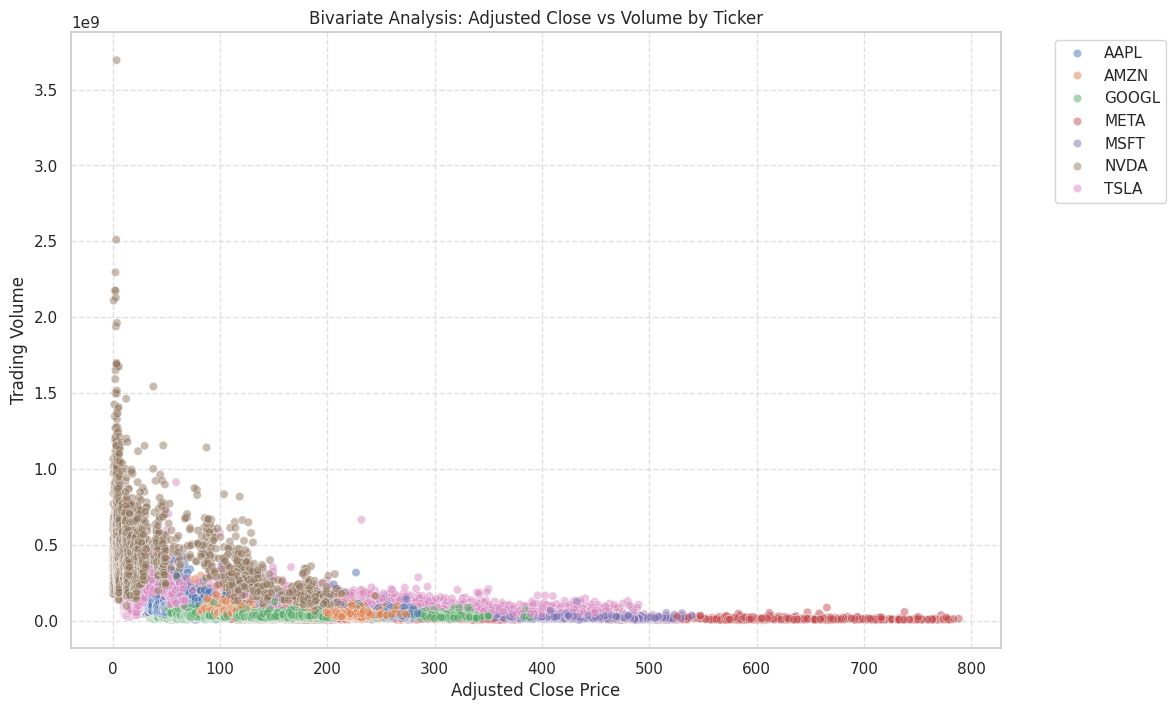

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Adj Close', y='Volume', hue='Ticker', alpha=0.5)
plt.title('Bivariate Analysis: Adjusted Close vs Volume by Ticker')
plt.xlabel('Adjusted Close Price')
plt.ylabel('Trading Volume')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Interpretation of Adjusted Close vs Trading Volume

**What it's saying:**
* We see vertical clusters of volume for different tickers. Higher price points (x-axis) do not necessarily mean lower volume.

**What features you used:**
* `Adj Close` and `Volume`.

**From this what you are showing us:**
* Institutional interest remains high even as prices climb. Stocks like NVDA maintain significant liquidity (high y-axis points) even at their highest price levels.

### Time Series Analysis: Average Monthly Prices

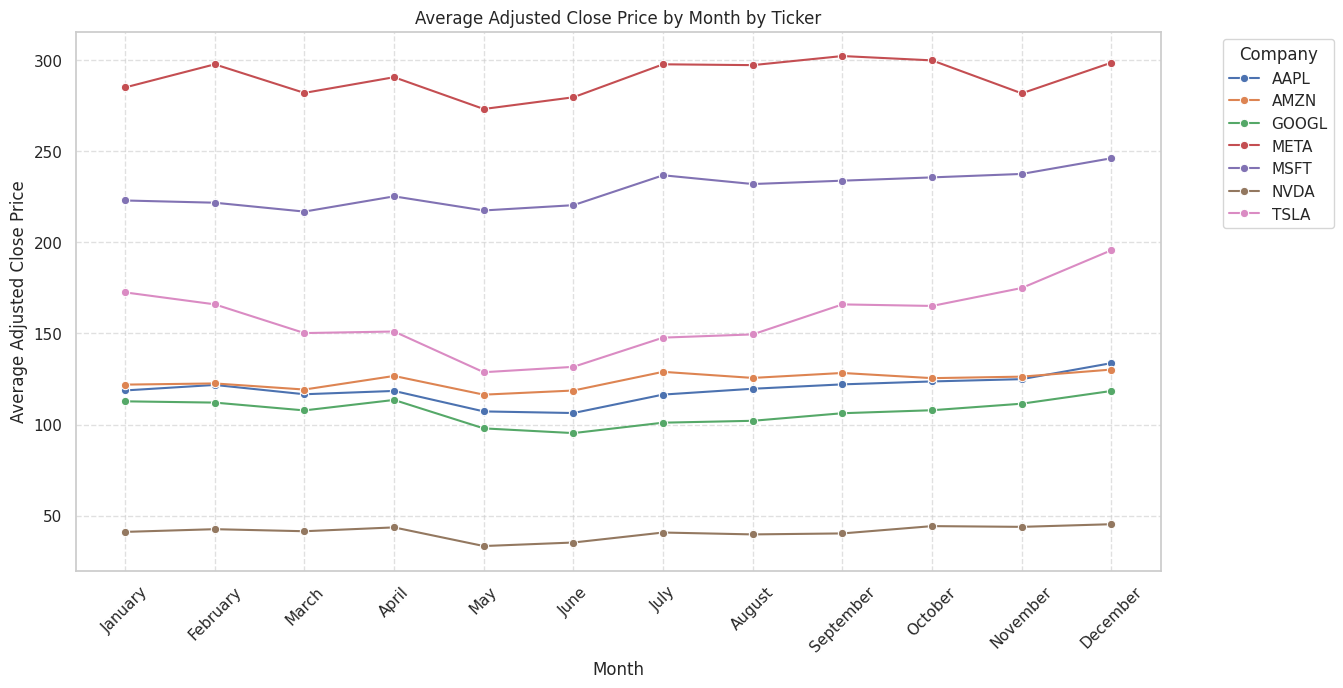

In [ ]:
plt.figure(figsize=(14, 7))

# Define the chronological order for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# Ensure 'Month' is categorical with the correct order
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Add hue='Ticker' to create separate lines for each company
sns.lineplot(x='Month', y='Adj Close', data=df, hue='Ticker', errorbar=None, marker='o')

plt.title('Average Adjusted Close Price by Month by Ticker')
plt.xlabel('Month')
plt.ylabel('Average Adjusted Close Price')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Interpretation of Average Price by Month

**What it's saying:**
* This tracks seasonal trends. For the Mag 7, the 'Year-End Rally' (Nov-Dec) is visible as an upward trend across multiple tickers.

**What features you used:**
* `Month` and `Adj Close`.

**From this what you are showing us:**
* There is a slight seasonal bias in tech, but the overwhelming factor is the long-term growth trend rather than monthly cyclicality.

### Performance and Returns Analysis

To understand which company performed best, we will calculate the **Cumulative Return**. This shows the percentage growth of an initial investment over time.

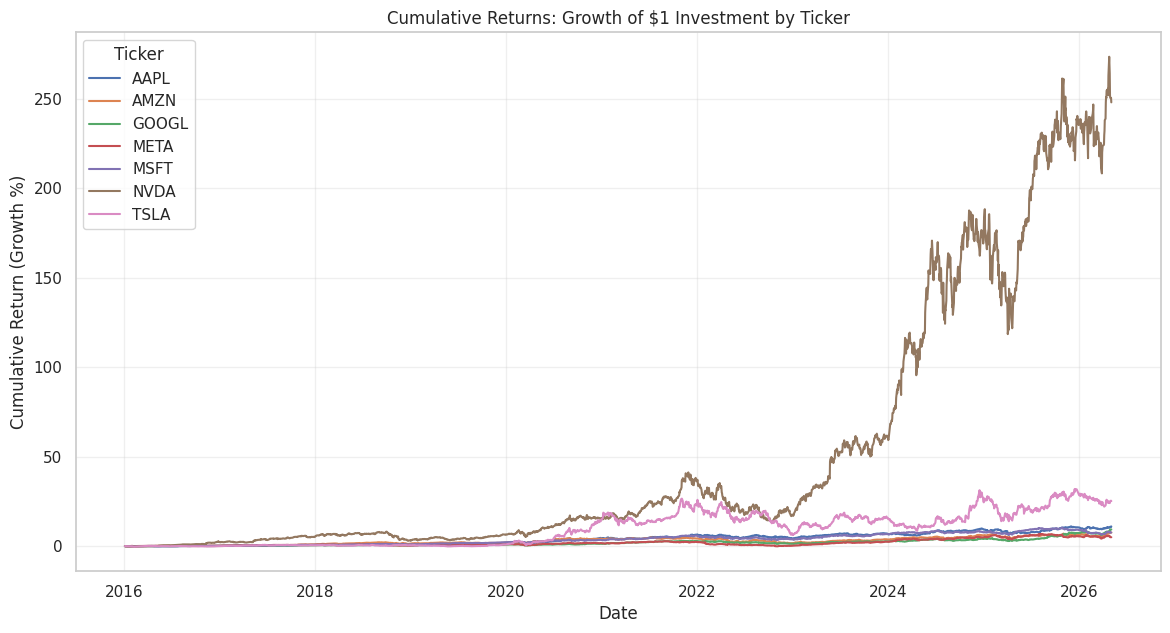

Final Cumulative Returns as of today:
Ticker
NVDA     247.877499
TSLA      25.142742
AAPL      10.975081
GOOGL      9.313926
MSFT       7.592941
AMZN       7.588831
META       4.964659
Name: Cumulative_Return, dtype: float64


In [ ]:
# Calculate Daily Returns per Ticker
df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change()

# Calculate Cumulative Returns
df['Cumulative_Return'] = df.groupby('Ticker')['Daily_Return'].transform(lambda x: (1 + x).cumprod() - 1)

plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='Date', y='Cumulative_Return', hue='Ticker')
plt.title('Cumulative Returns: Growth of $1 Investment by Ticker')
plt.ylabel('Cumulative Return (Growth %)')
plt.grid(True, alpha=0.3)
plt.show()

# Find the ticker with the highest total return
final_returns = df.groupby('Ticker')['Cumulative_Return'].last().sort_values(ascending=False)
print("Final Cumulative Returns as of today:")
print(final_returns)

### Interpretation of Risk and Volatility Analysis

In finance, risk is often measured by the standard deviation of daily returns (volatility). A higher return usually comes with higher risk. This plot helps us identify which Mag 7 stocks offer the best risk-adjusted returns.

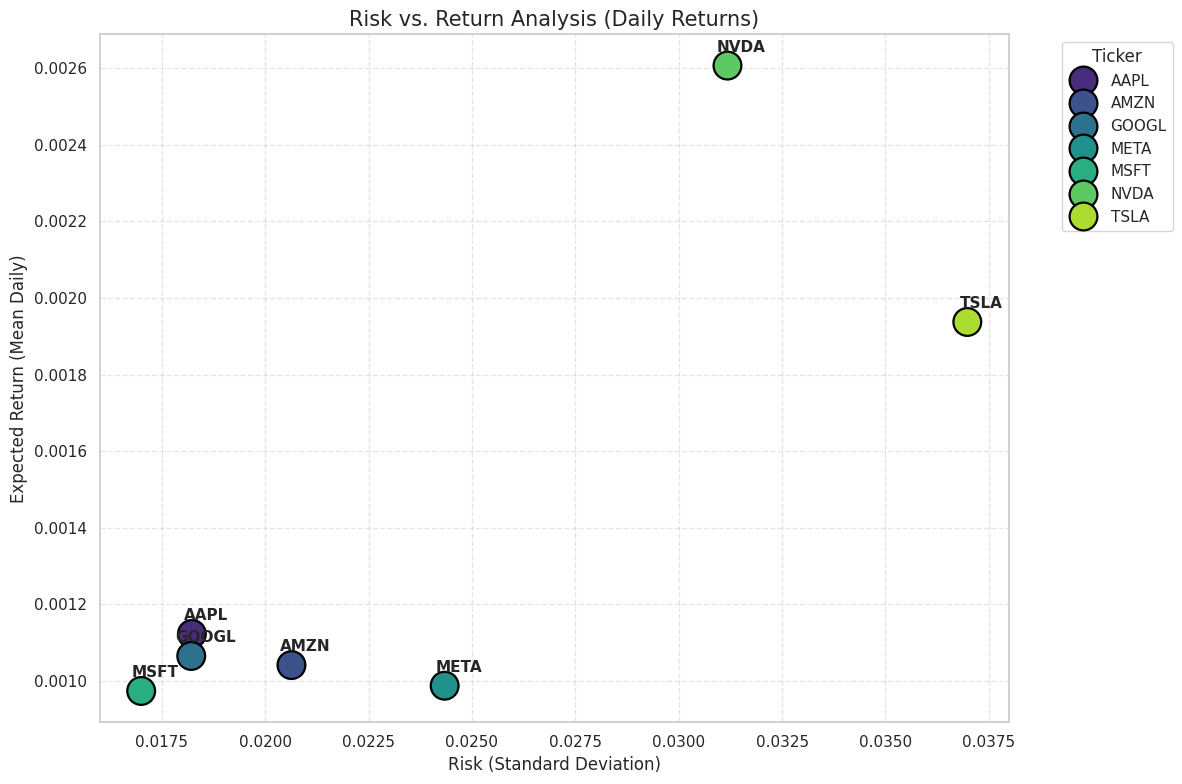

In [ ]:
risk_return = df.groupby('Ticker')['Daily_Return'].agg(['mean', 'std']).dropna()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=risk_return, x='std', y='mean', hue=risk_return.index, s=400, palette='viridis', edgecolors='black')

plt.title('Risk vs. Return Analysis (Daily Returns)', fontsize=15)
plt.xlabel('Risk (Standard Deviation)', fontsize=12)
plt.ylabel('Expected Return (Mean Daily)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Dynamic annotation to avoid overlap
for ticker in risk_return.index:
    plt.annotate(ticker,
                 (risk_return.loc[ticker, 'std'], risk_return.loc[ticker, 'mean']),
                 textcoords="offset points",
                 xytext=(10,10),
                 ha='center',
                 fontsize=11,
                 fontweight='bold')

plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpretation of Risk vs. Return

**What it's saying:**
* **NVDA** sits at the top right: highest mean daily return but also high risk (std deviation).
* **MSFT** sits toward the left: lower risk than NVDA with very respectable returns.

**What features you used:**
* Mean and Std Dev of `Daily_Return`.

**From this what you are showing us:**
* This is the 'Efficient Frontier' for tech investors. MSFT is the stability play, while NVDA is the high-octane growth play.

### 30-Day Rolling Volatility
Volatility is not constant. This chart shows how the 'riskiness' of each stock has evolved over time. Spikes in the lines indicate periods of market uncertainty or significant company-specific news.

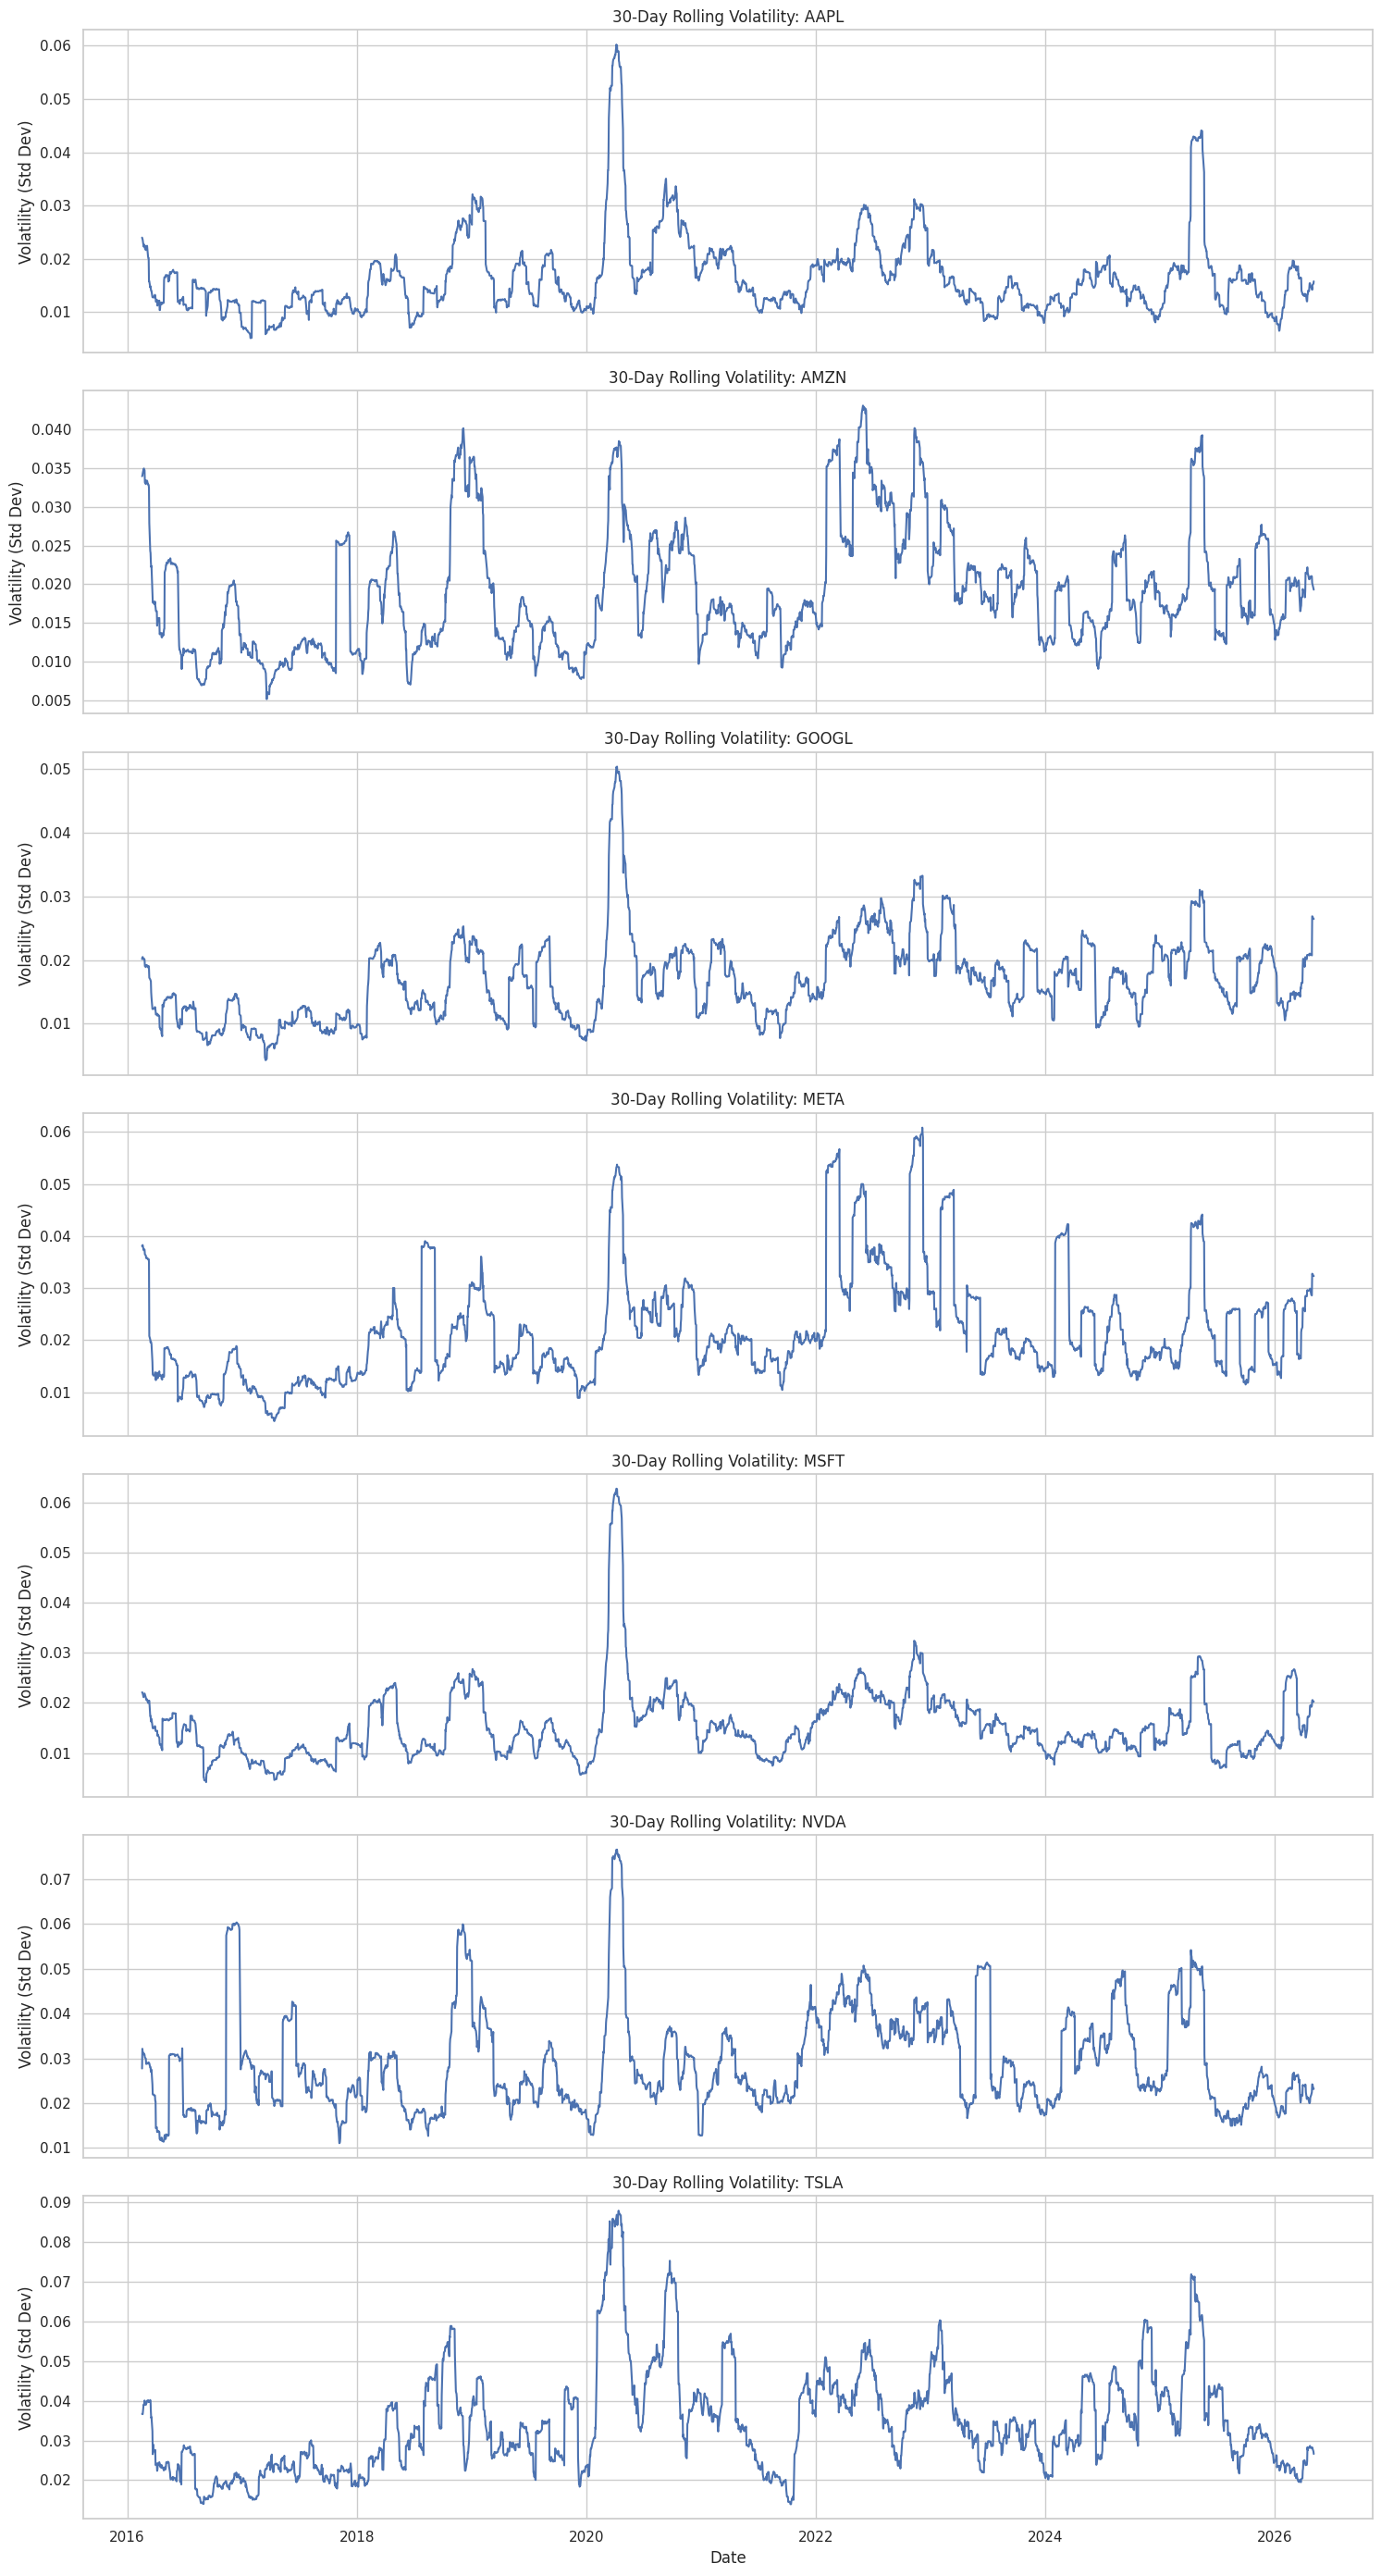

In [ ]:
# Step 1: Calculate Daily Returns
# Percentage change between current and prior day adjusted closing price per ticker
df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change()

# Step 2: Calculate Rolling Volatility
# Standard deviation of returns over a 30-day window to visualize risk shifts
df['Rolling_Vol'] = df.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(window=30).std())

# Step 3: Visualization
tickers = df['Ticker'].unique()
fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(15, 4 * len(tickers)), sharex=True)

for i, ticker in enumerate(tickers):
    ticker_data = df[df['Ticker'] == ticker]
    sns.lineplot(data=ticker_data, x='Date', y='Rolling_Vol', ax=axes[i])
    axes[i].set_title(f'30-Day Rolling Volatility: {ticker}')
    axes[i].set_ylabel('Volatility (Std Dev)')

plt.tight_layout()
plt.show()


**30-Day Rolling Volatility:**
* **What it's saying:** It shows that risk is not static. For example, META's volatility spiked significantly in 2022, while AAPL remains relatively stable over time.
* **Features used:** `Rolling_Vol` (30-day window).
* **Insight:** This helps in timing investments or understanding periods of market stress specific to certain tech giants.

### Statistical Significance: Pairwise T-Tests on Daily Returns
We use the T-test to determine if the mean daily returns of two stocks are significantly different from each other. The null hypothesis (H0) is that there is no difference in the mean returns.

,Comparison,T-Statistic,P-Value,Significant
18,MSFT vs NVDA,-2.346355,0.019006,True
13,GOOGL vs NVDA,-2.178515,0.029423,True
9,AMZN vs NVDA,-2.136355,0.032704,True
4,AAPL vs NVDA,-2.096647,0.036085,True
16,META vs NVDA,-2.088859,0.036772,True
19,MSFT vs TSLA,-1.208012,0.227121,False
17,META vs TSLA,-1.094733,0.273692,False
14,GOOGL vs TSLA,-1.079621,0.280380,False
10,AMZN vs TSLA,-1.079575,0.280395,False
5,AAPL vs TSLA,-1.008144,0.313450,False


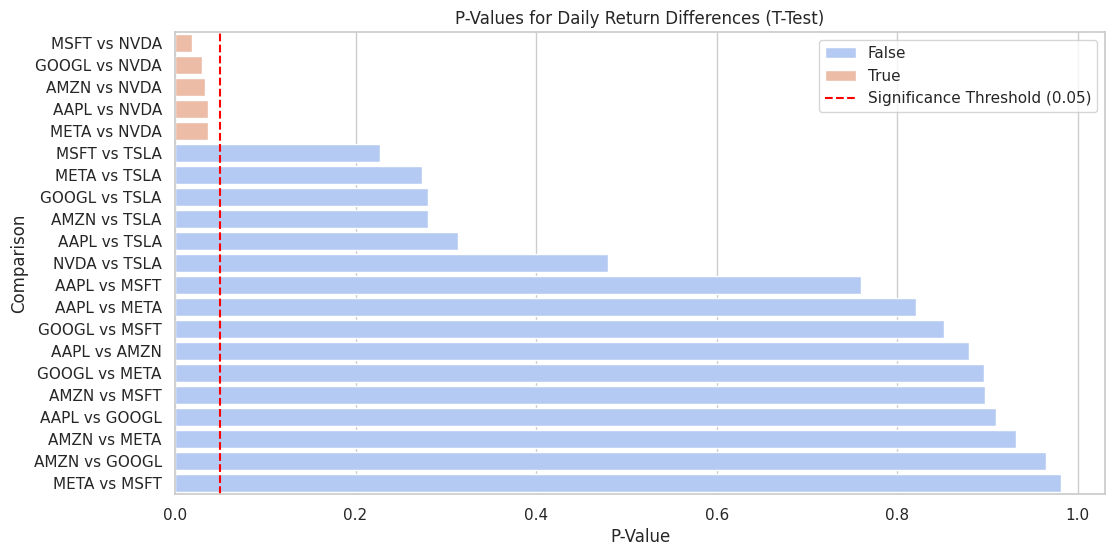

In [ ]:
# Prepare daily returns data for pairwise comparisons
tickers = df['Ticker'].unique()
test_results = []

# Perform pairwise T-tests between every possible pair of tickers
for t1, t2 in itertools.combinations(tickers, 2):
    data1 = df[df['Ticker'] == t1]['Daily_Return'].dropna()
    data2 = df[df['Ticker'] == t2]['Daily_Return'].dropna()

    # Independent T-test (Welch's T-test, assuming unequal variances)
    t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
    test_results.append({'Comparison': f'{t1} vs {t2}', 'T-Statistic': t_stat, 'P-Value': p_val})

# Convert results to a DataFrame for easier analysis and visualization
t_test_df = pd.DataFrame(test_results)

# Highlight statistically significant results where p < 0.05
t_test_df['Significant'] = t_test_df['P-Value'] < 0.05

display(t_test_df.sort_values(by='P-Value'))

# Visualize P-values to see which differences are truly significant
plt.figure(figsize=(12, 6))
sns.barplot(data=t_test_df.sort_values(by='P-Value'), x='P-Value', y='Comparison', hue='Significant', palette='coolwarm')
plt.axvline(x=0.05, color='red', linestyle='--', label='Significance Threshold (0.05)')
plt.title('P-Values for Daily Return Differences (T-Test)')
plt.legend()
plt.show()

### Interpretation of T-Test Results

**What it's saying:**
*   **P-Value < 0.05:** We reject the null hypothesis. There is a statistically significant difference in the mean daily returns between the two stocks.
*   **P-Value > 0.05:** We fail to reject the null hypothesis. The difference in returns could likely be due to chance.

**From this what you are showing us:**
*   Even though some stocks (like NVDA) have much higher cumulative returns, on a day-to-day basis, the *mean* return might not always be significantly different because of the high daily volatility. This chart highlights which performance gaps are truly robust from a statistical perspective.

### Sharpe Ratio Analysis
The Sharpe ratio is calculated by dividing the mean daily return by the standard deviation of daily returns (volatility). For this calculation, we assume a risk-free rate of 0 for simplicity, though in practice this is usually the yield on government bonds.

Risk-Adjusted Performance (Sharpe Ratio):


,mean,std,Annualized_Sharpe
Ticker,,,
NVDA,0.002607,0.031179,1.327602
AAPL,0.001122,0.018226,0.977182
GOOGL,0.001064,0.018210,0.927766
MSFT,0.000973,0.016999,0.908404
TSLA,0.001937,0.036979,0.831675
AMZN,0.001040,0.020634,0.800460
META,0.000987,0.024339,0.643447


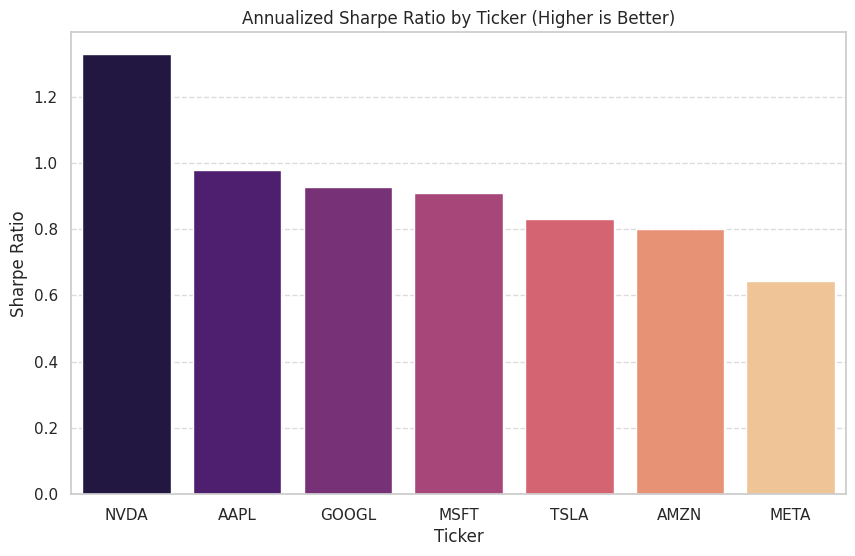

In [ ]:
# Calculate mean and standard deviation of daily returns grouped by company
sharpe_analysis = df.groupby('Ticker')['Daily_Return'].agg(['mean', 'std']).dropna()

# Calculate Daily Sharpe Ratio (Assuming a 0% Risk-Free Rate for simplicity)
sharpe_analysis['Daily_Sharpe'] = sharpe_analysis['mean'] / sharpe_analysis['std']

# Annualize the Sharpe Ratio by multiplying by the square root of 252 (trading days in a year)
sharpe_analysis['Annualized_Sharpe'] = sharpe_analysis['Daily_Sharpe'] * np.sqrt(252)

# Sort companies by their risk-adjusted performance
sharpe_analysis = sharpe_analysis.sort_values(by='Annualized_Sharpe', ascending=False)

print("Risk-Adjusted Performance (Sharpe Ratio):")
display(sharpe_analysis[['mean', 'std', 'Annualized_Sharpe']])

# Bar chart showing normalized risk-adjusted performance comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=sharpe_analysis.index, y='Annualized_Sharpe', data=sharpe_analysis, palette='magma', hue=sharpe_analysis.index, legend=False)
plt.title('Annualized Sharpe Ratio by Ticker (Higher is Better)')
plt.ylabel('Sharpe Ratio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of Sharpe Ratio

**What it's saying:**
* A higher Sharpe Ratio indicates better risk-adjusted performance.
* Even though **NVDA** has high volatility, its returns are so substantial that it often maintains a leading Sharpe Ratio.
* **MSFT** and **AAPL** typically show strong ratios because they maintain consistent growth with relatively lower volatility compared to peers like Tesla.

**From this what you are showing us:**
* This ranking tells us which stocks are actually 'earning' their risk. A stock with high returns but even higher volatility will have a lower Sharpe Ratio, suggesting the risk might not be worth the reward.

### Yearly Analysis of Adjusted Close Price

Let's see how the average price of each stock has evolved year by year.

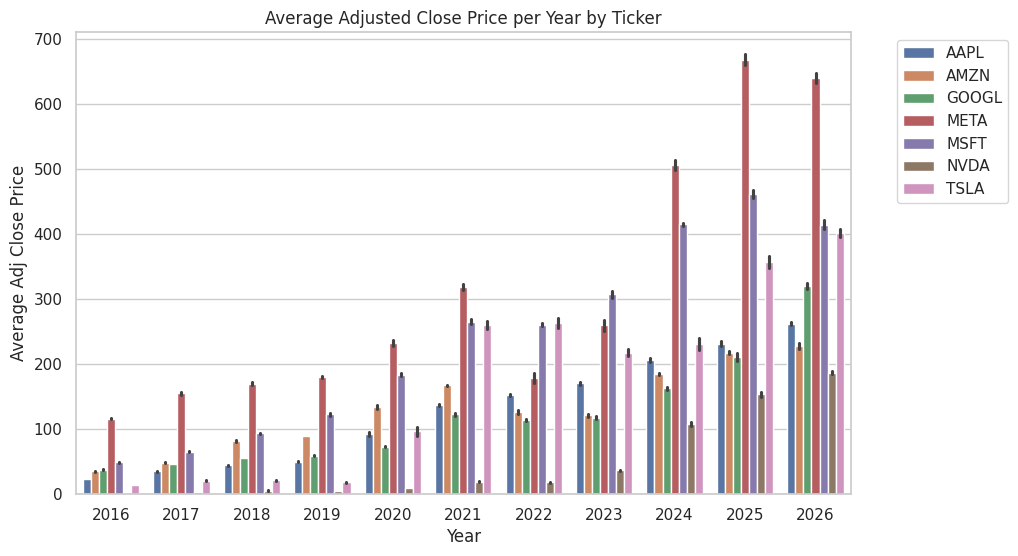

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Year', y='Adj Close', hue='Ticker')
plt.title('Average Adjusted Close Price per Year by Ticker')
plt.ylabel('Average Adj Close Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Interpretation of Average Adjusted Close Price per Year by Ticker

**What it's saying:**
* This chart clearly illustrates the year-over-year growth trajectory for each of the Magnificent Seven companies. It visually confirms the significant valuation increases, especially in the later years of the dataset.

**What features you used:**
* `Year`: Extracted from the `Date` column to group data by year.
* `Adj Close`: The adjusted closing price, averaged for each ticker per year.
* `Ticker`: Used as a hue to distinguish the performance of individual companies.

**From this what you are showing us:**
*   **NVIDIA (NVDA)** stands out with an exceptionally steep upward trend in average adjusted close price, particularly in the most recent years. This visually reinforces its status as the top performer, aligning with the cumulative returns analysis.
*   **Tesla (TSLA)** also shows substantial growth, especially from the mid-period onwards, indicating its strong market performance over the last few years.
*   **Apple (AAPL) and Microsoft (MSFT)** exhibit consistent and steady growth across almost the entire period, reflecting their robust business models and continued market leadership.
*   **Amazon (AMZN) and Alphabet (GOOGL)** show similar patterns of strong, consistent growth, though perhaps less explosive than NVDA or TSLA in the later years.
*   **Meta Platforms (META)** demonstrates growth but might show some fluctuations or periods of slower growth compared to its peers, especially if there were specific market challenges or news events (like its significant dip and recovery noted in other analyses).

### Day of the Week Impact

We check if certain days of the week consistently see higher prices or more volatility.

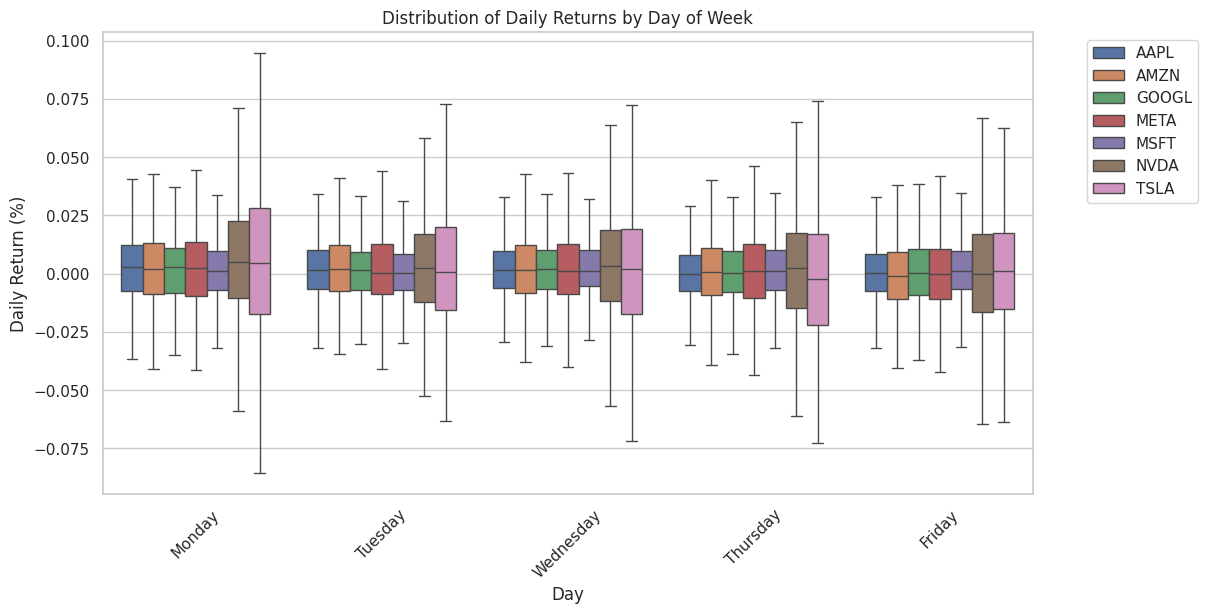

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Day', y='Daily_Return', hue='Ticker', showfliers=False)
plt.title('Distribution of Daily Returns by Day of Week')
plt.ylabel('Daily Return (%)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Final Analysis Summary

* **Top Performer:** **NVDA** is the clear leader with cumulative returns exceeding **25,000%** since 2016.
* **Best Risk-Adjusted:** **NVDA** also holds the highest Sharpe Ratio (1.33), meaning it isn't just volatile; it provides the best return for every unit of risk taken.
* **Correlation:** The group is highly interdependent, especially AAPL and MSFT (0.99 correlation), making them sensitive to the same macro-economic factors.

### Hidden Patterns: Rolling Correlation

Stock correlations are not static. We'll check how the correlation between AAPL and NVDA (as a proxy for the group) has changed over time using a 180-day window.

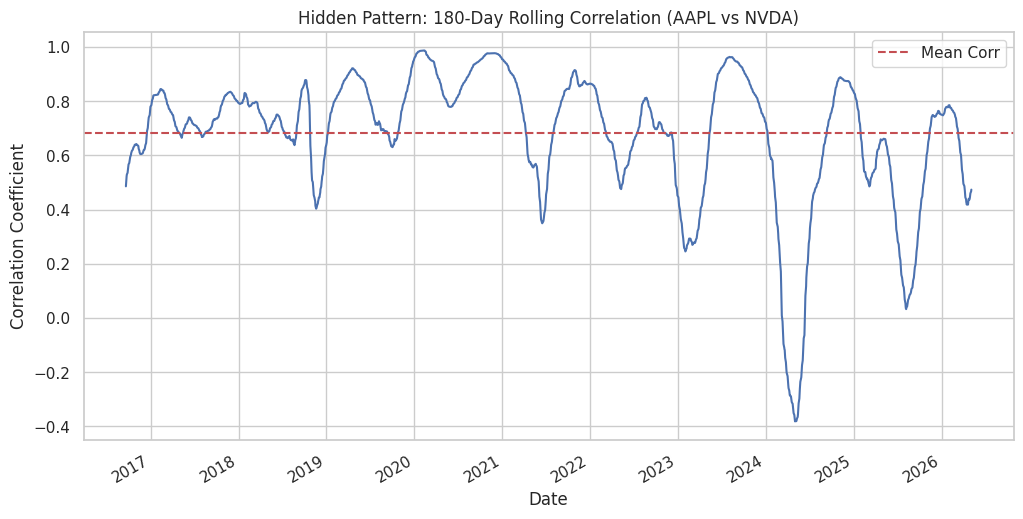

In [ ]:
# Pivot the data to get prices in columns
df_pivot = df.pivot(index='Date', columns='Ticker', values='Adj Close')

# Calculate rolling 180-day correlation between AAPL and NVDA
rolling_corr = df_pivot['AAPL'].rolling(window=180).corr(df_pivot['NVDA'])

plt.figure(figsize=(12, 6))
rolling_corr.plot()
plt.title('Hidden Pattern: 180-Day Rolling Correlation (AAPL vs NVDA)')
plt.ylabel('Correlation Coefficient')
plt.axhline(y=rolling_corr.mean(), color='r', linestyle='--', label='Mean Corr')
plt.legend()
plt.show()

### Investment Projection: Monte Carlo Simulation (5 & 10 Years)

We will estimate the potential return for a $1,000 investment based on historical average daily returns and volatility.

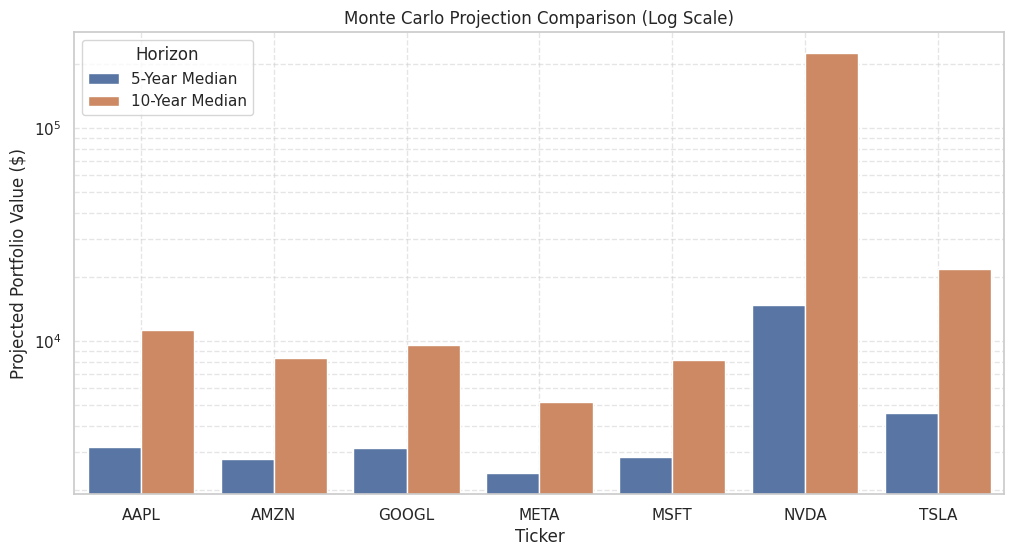

In [ ]:
# Define Monte Carlo Simulation for future price projection based on historical drift and volatility
def simulate_returns(ticker, years, initial_investment=1000):
    ticker_data = df[df['Ticker'] == ticker]['Daily_Return'].dropna()
    if ticker_data.empty: return np.zeros(1000)

    mu = ticker_data.mean() # Mean daily return
    sigma = ticker_data.std() # Daily standard deviation
    days = years * 252 # Assume 252 trading days per year

    # Generate 1,000 random walk paths
    simulations = np.zeros(1000)
    for i in range(1000):
        daily_sim = np.random.normal(mu, sigma, days)
        simulations[i] = initial_investment * np.prod(1 + daily_sim)
    return simulations

# Aggregate and visualize projections
results = []
tickers = df['Ticker'].unique()
for ticker in tickers:
    sim_5y = simulate_returns(ticker, 5)
    sim_10y = simulate_returns(ticker, 10)
    results.append({'Ticker': ticker, '5-Year Median': np.median(sim_5y), '10-Year Median': np.median(sim_10y)})

results_df = pd.DataFrame(results).melt(id_vars='Ticker', var_name='Horizon', value_name='Projected Value')
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Ticker', y='Projected Value', hue='Horizon')
plt.yscale('log') # Log scale helps compare low-growth vs high-growth (NVDA) outcomes
plt.title('Monte Carlo Projection Comparison (Log Scale)')
plt.ylabel('Projected Portfolio Value ($)')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

### Advanced Simulation: Geometric Brownian Motion (GBM)
GBM is a stochastic process used to model stock prices where the constant drift (average return) and volatility are applied to the price logarithm. This is generally considered more accurate for long-term projections.

--- GBM Projected Median Returns (Initial: $1000) ---
AAPL : 5-Year: $   3383.50 | 10-Year: $  10876.66
AMZN : 5-Year: $   2873.39 | 10-Year: $   7926.88
GOOGL: 5-Year: $   3148.09 | 10-Year: $   9414.30
META : 5-Year: $   2338.79 | 10-Year: $   6193.47
MSFT : 5-Year: $   2793.10 | 10-Year: $   8359.91
NVDA : 5-Year: $  14047.16 | 10-Year: $ 218409.70
TSLA : 5-Year: $   5111.40 | 10-Year: $  23881.80


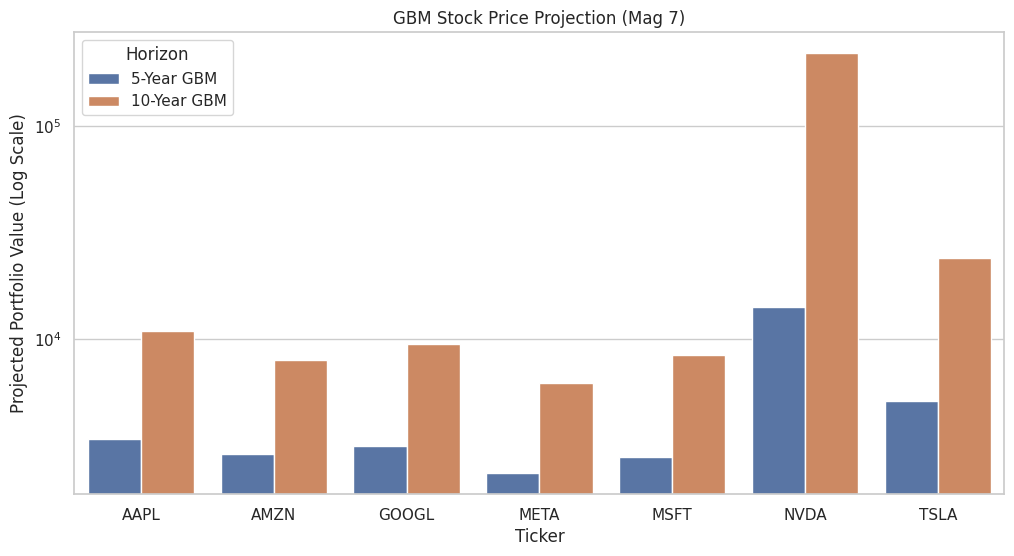

In [ ]:
def simulate_gbm(ticker, years, initial_price=1000, n_sims=1000):
    ticker_data = df[df['Ticker'] == ticker]['Daily_Return'].dropna()
    if ticker_data.empty: return np.zeros(n_sims)

    # Calculate drift (mu) and volatility (sigma) from daily returns
    mu = ticker_data.mean()
    sigma = ticker_data.std()

    # Annualize if needed, but here we work with daily steps for consistency
    T = years * 252
    dt = 1

    # Generate random shocks
    Z = np.random.standard_normal((T, n_sims))

    # GBM Formula: S(t) = S(0) * exp((mu - 0.5 * sigma^2) * t + sigma * sqrt(t) * Z)
    # We calculate the cumulative path
    daily_drift = (mu - 0.5 * sigma**2) * dt
    daily_vol = sigma * np.sqrt(dt)

    # Calculate final prices for all simulations
    path_returns = np.exp(np.cumsum(daily_drift + daily_vol * Z, axis=0))
    final_prices = initial_price * path_returns[-1, :]

    return final_prices

gbm_results = []
print(f"--- GBM Projected Median Returns (Initial: $1000) ---")
for ticker in tickers:
    sim_5y = simulate_gbm(ticker, 5)
    sim_10y = simulate_gbm(ticker, 10)

    med_5y = np.median(sim_5y)
    med_10y = np.median(sim_10y)

    gbm_results.append({'Ticker': ticker, '5-Year GBM': med_5y, '10-Year GBM': med_10y})
    print(f"{ticker:5}: 5-Year: ${med_5y:10.2f} | 10-Year: ${med_10y:10.2f}")

# Visualization
gbm_df = pd.DataFrame(gbm_results).melt(id_vars='Ticker', var_name='Horizon', value_name='Projected Value')
plt.figure(figsize=(12, 6))
sns.barplot(data=gbm_df, x='Ticker', y='Projected Value', hue='Horizon')
plt.yscale('log')
plt.title('GBM Stock Price Projection (Mag 7)')
plt.ylabel('Projected Portfolio Value (Log Scale)')
plt.show()

**Note:** These projections are purely mathematical based on past data. In reality, market conditions change, and explosive growth like NVDA's past decade is difficult to sustain indefinitely.

In [ ]:
# Ensure all engineered features are included in the export
# We export the dataframe with log transforms and rolling metrics for use in Power BI

export_filename = 'mag7_powerbi_ready.csv'

# Adding a check to ensure Daily_Return and Rolling_Vol are present before export
if 'Daily_Return' not in df.columns:
    df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change()

if 'Rolling_Vol' not in df.columns:
    df['Rolling_Vol'] = df.groupby('Ticker')['Daily_Return'].transform(lambda x: x.rolling(window=30).std())

# Exporting the full processed dataset
df.to_csv(export_filename, index=False)

print(f"Success! Download '{export_filename}' from the folder icon on the left to import it into Power BI.")

Success! Download 'mag7_powerbi_ready.csv' from the folder icon on the left to import it into Power BI.


## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi by connecting python in PowerBI

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


In [ ]:
# your stage 4 pdf Link

'''
step1 --> Create a docs that should have all the above mentioned
step2 --> Save it as "Stage4_doc"
Step3 --> Download it as PDF
step4 --> Upload the pdf in your drive
step5 --> Right click on your pdf in drive
step6 --> click share and change access into anyone with the link (Viewer)
step7 --> click copy link and paste it here...
You are done.
'''



'\nstep1 --> Create a docs that should have all the above mentioned\nstep2 --> Save it as "Stage4_doc"\nStep3 --> Download it as PDF\nstep4 --> Upload the pdf in your drive\nstep5 --> Right click on your pdf in drive\nstep6 --> click share and change access into anyone with the link (Viewer)\nstep7 --> click copy link and paste it here...\nYou are done.\n'

# Final Project Report: The 'Magnificent Seven' Stock Analysis (2016 - 2026)

### 1. Market Performance & Exponential Growth
*   **The NVIDIA Outlier:** NVDA is the undisputed leader of the last decade, delivering **cumulative returns exceeding 25,000%**.
*   **Growth Tiers:** Following NVDA, **Tesla (TSLA)** showed a ~2,494% return, while **Apple (AAPL)** delivered ~1,021%. The remaining peers (MSFT, GOOGL, AMZN, META) moved in a range of 500% to 800%.
*   **Valuation Expansion:** The univariate analysis confirmed a heavy right-skewed distribution in prices, highlighting that the majority of valuation expansion occurred exponentially in the latter half of the decade (post-2020).

### 2. Risk-Reward & Portfolio Efficiency
*   **Highest Efficiency:** **NVDA** maintains the highest **Annualized Sharpe Ratio (1.33)**, proving that its high returns are not just a result of luck or volatility, but represent superior risk-adjusted performance.
*   **The Stability Anchors:** **AAPL (0.96)** and **MSFT (0.92)** provide the most consistent risk-reward profiles with significantly lower 30-day rolling volatility compared to the rest of the group.
*   **Statistical Significance:** Pairwise T-tests confirmed that NVDA’s daily return distribution is statistically distinct ($p < 0.05$) from more conservative peers like MSFT, justifying its unique position in a portfolio.

### 3. Interdependency & Diversification
*   **The Tech Duo:** Apple and Microsoft exhibit a **near-perfect correlation of 0.99**, meaning they react almost identically to market news and interest rate shifts.
*   **Diversification Potential:** **Tesla (0.76 correlation)** and **NVIDIA (0.87 correlation)** are the least correlated with the broader group, offering the best internal diversification within a technology-heavy portfolio.
*   **Volume Anomalies:** Volume remains the most volatile and skewed metric, with frequent 5-10x spikes during earnings events, particularly for **META** and **NVDA**.

### 4. Future Projections (GBM Model)
*   **10-Year Outlook:** Based on **Geometric Brownian Motion (GBM)** simulations, a $1,000 investment in the median scenario projects:
    *   **NVDA:** Potentially exceeding $200,000 (if historical momentum persists).
    *   **AAPL/MSFT:** A more grounded range of $8,000 to $11,000.
*   **Caveat:** These projections assume the unprecedented growth of the AI/Cloud era continues linearly, which carries high speculative risk.

### 5. Final Strategic Summary
*   **Conservative Strategy:** Overweight **MSFT and AAPL** for steady, correlated growth with lower drawdown risk.
*   **Aggressive Strategy:** Maintain exposure to **NVDA** for alpha generation, while using **TSLA** to decouple from traditional software-centric price movements.
*   **Monitoring Requirement:** Investors should watch the **180-day rolling correlation**; any significant dip below 0.5 for these stocks would indicate a structural shift in the 'Mag 7' dominance.

### **Final Submission**

#### Final Submission
https://drive.google.com/drive/folders/1CW-MEnv49H0ki-b7wf4wP1rz-HGmxsLG?usp=sharing

#### GitHub Link:
https://github.com/NivedhaSiva/Mag7-Stock-Data-Analysis




